In [1]:
# Cell 1: Imports
import sys
import os
sys.path.append(os.path.abspath('..'))  # Add project root to path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import (
    load_raw_data, 
    basic_cleaning, 
    get_data_summary,
    calculate_rfm
)

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Setup complete")

✅ Setup complete


In [3]:
# Cell 2: Load Raw Data
df = load_raw_data("../data/raw/alternate_data.csv")
df = basic_cleaning(df)

print(df.head())

Data loaded successfully. Shape: (95662, 16)
Basic cleaning completed.
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6  

In [4]:
# Cell 3: Data Overview
get_data_summary(df)

=== Dataset Overview ===
Shape: (95662, 20)

Columns:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear']

Data Types:
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,2,15,11,2018
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,2,15,11,2018
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,2,15,11,2018
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,3,15,11,2018
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,3,15,11,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95657,TransactionId_89881,BatchId_96668,AccountId_4841,SubscriptionId_3829,CustomerId_3078,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-1000.0,1000,2019-02-13 09:54:09+00:00,2,0,9,13,2,2019
95658,TransactionId_91597,BatchId_3503,AccountId_3439,SubscriptionId_2643,CustomerId_3874,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2019-02-13 09:54:25+00:00,2,0,9,13,2,2019
95659,TransactionId_82501,BatchId_118602,AccountId_4841,SubscriptionId_3829,CustomerId_3874,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2019-02-13 09:54:35+00:00,2,0,9,13,2,2019
95660,TransactionId_136354,BatchId_70924,AccountId_1346,SubscriptionId_652,CustomerId_1709,UGX,256,ProviderId_6,ProductId_19,tv,ChannelId_3,3000.0,3000,2019-02-13 10:01:10+00:00,2,0,10,13,2,2019


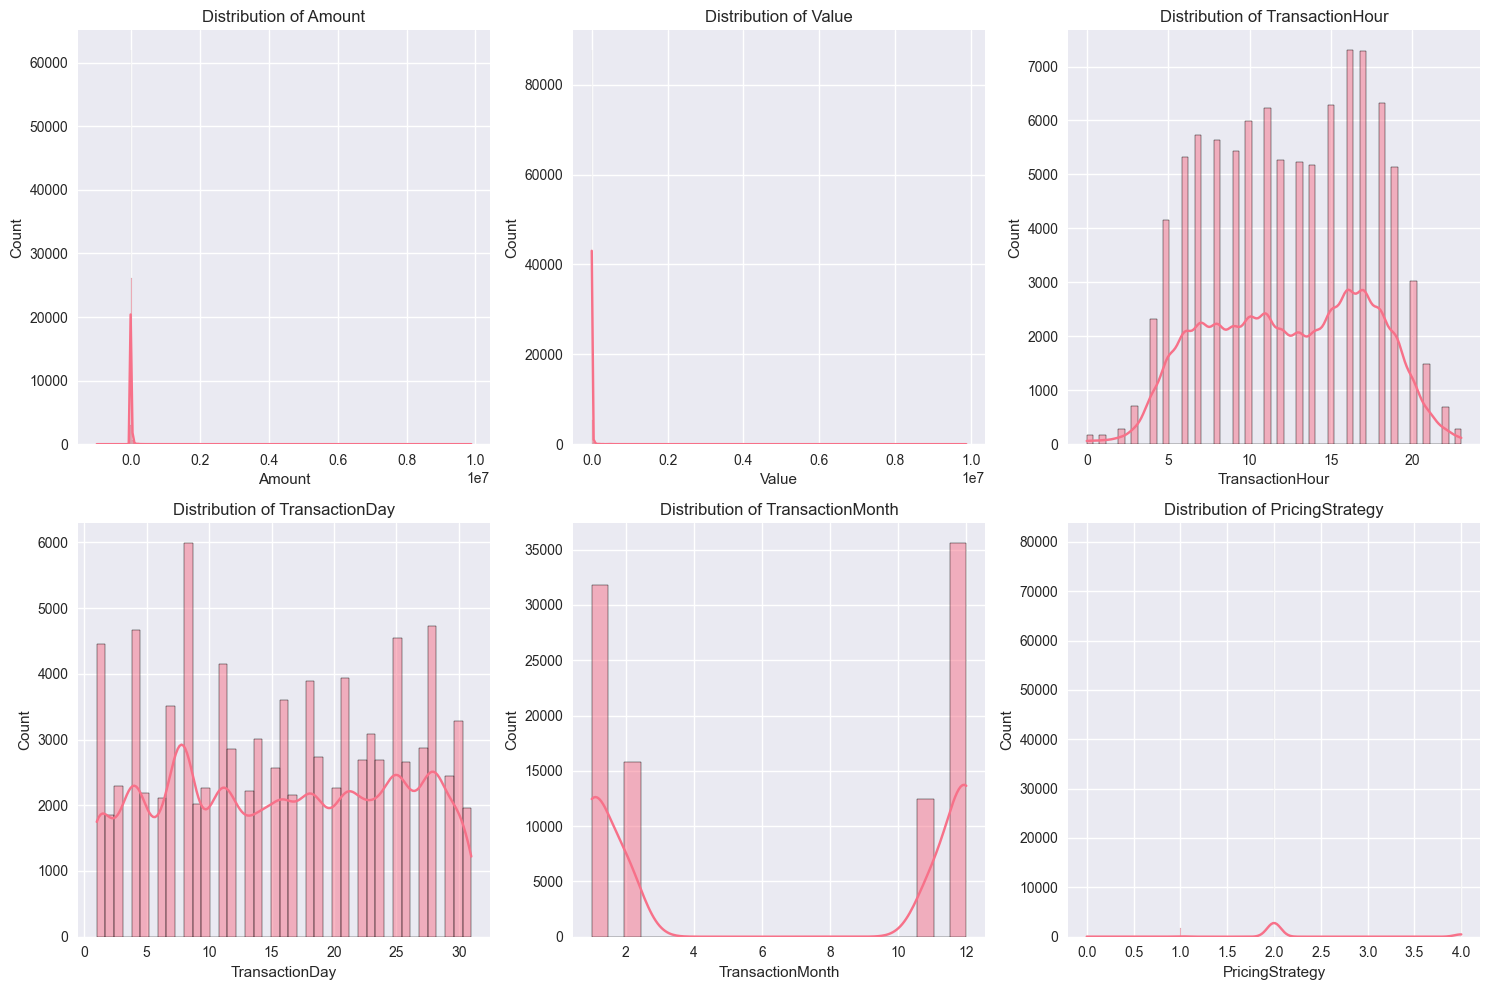

In [5]:
# Cell 4: Numerical Features Distribution
numerical_cols = ['Amount', 'Value', 'TransactionHour', 'TransactionDay', 
                 'TransactionMonth', 'PricingStrategy']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

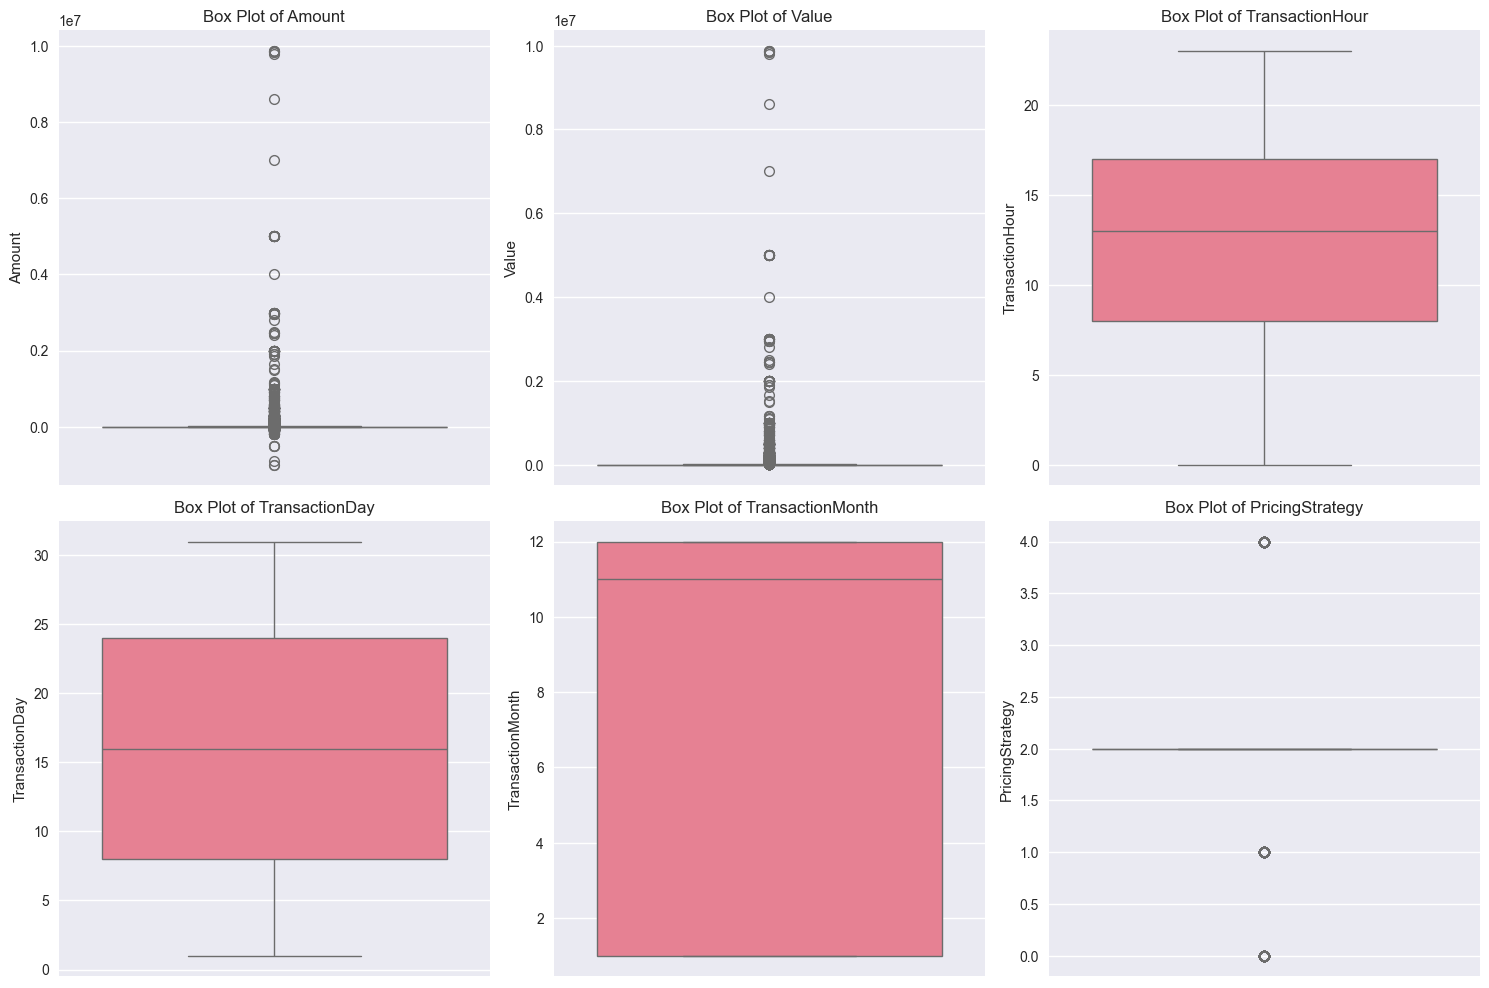

In [6]:
# Cell 5: Box Plots - Outlier Detection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if col in df.columns:
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

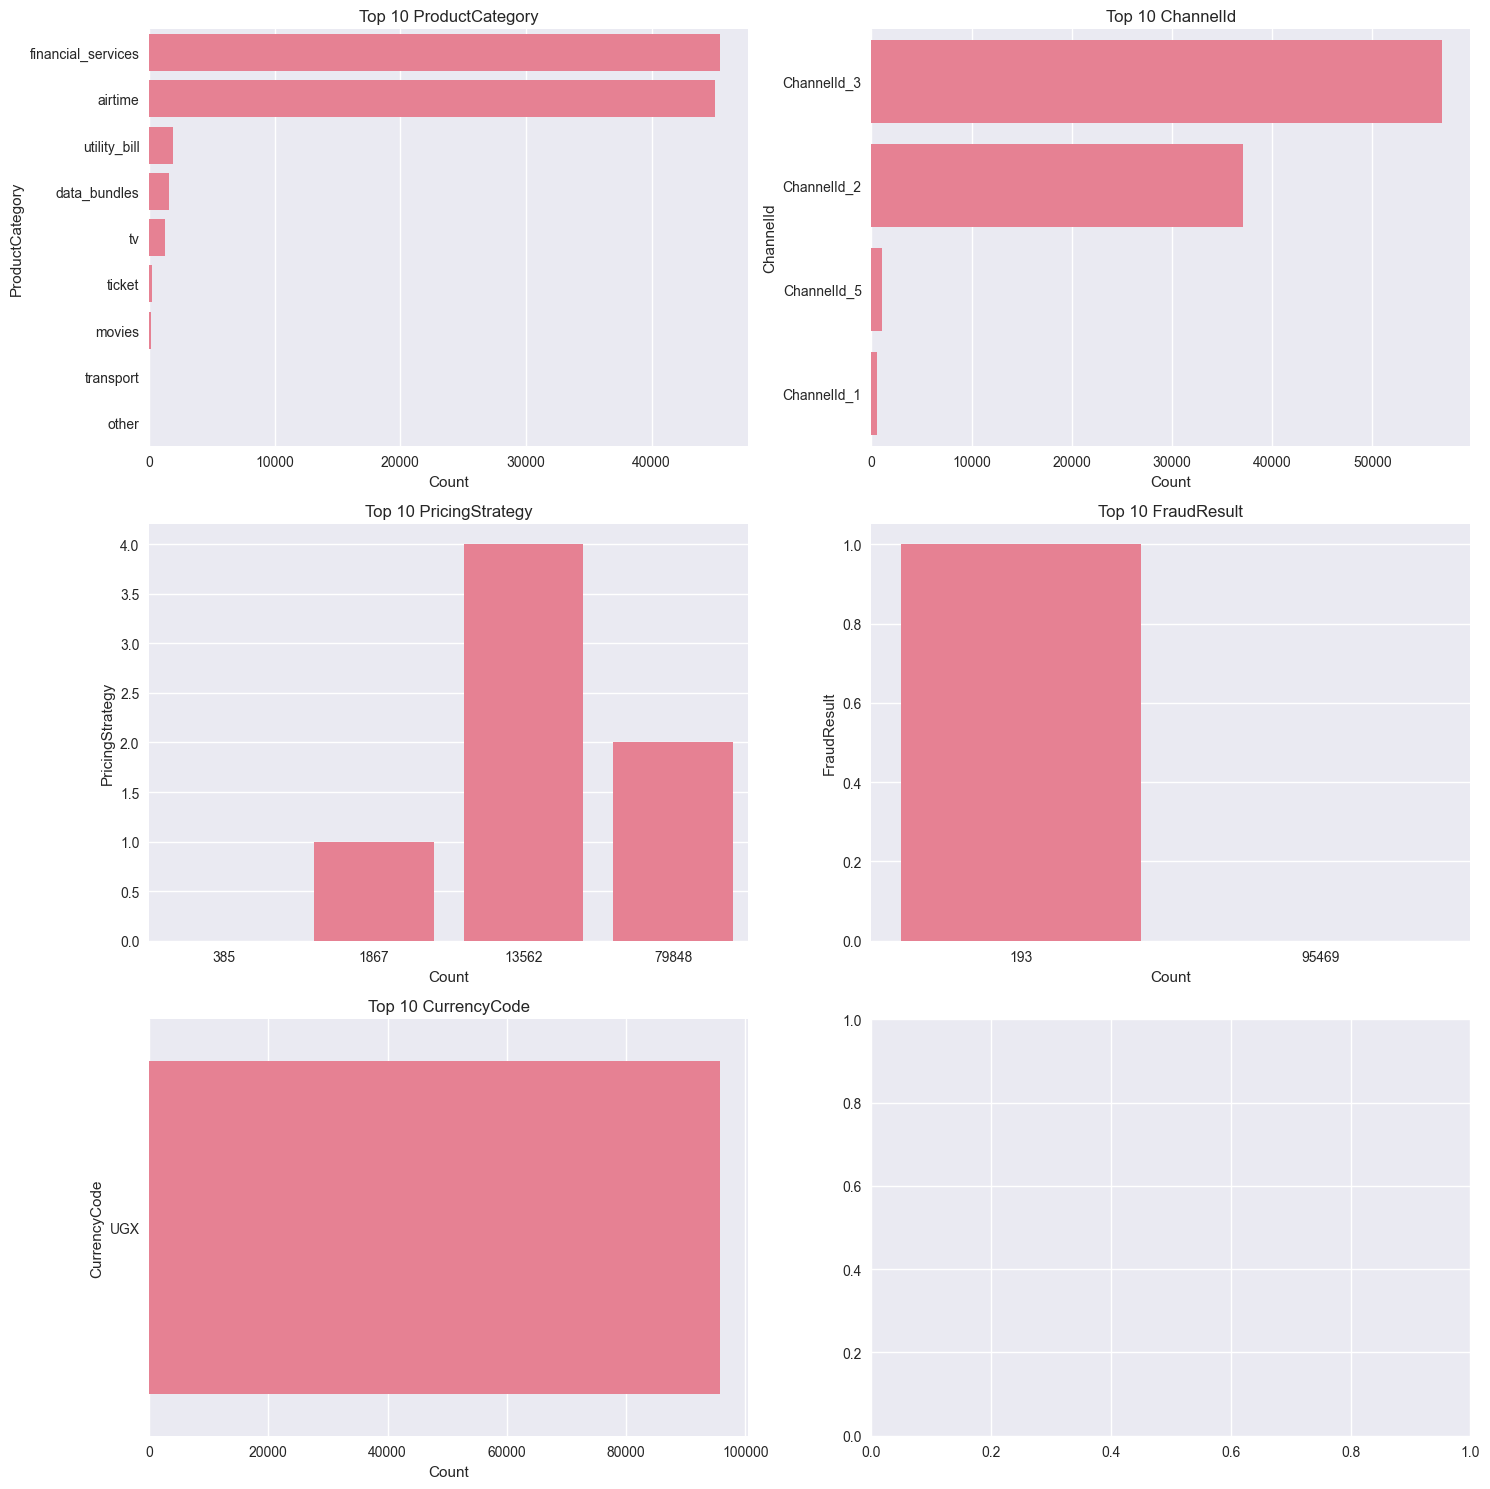

In [7]:
# Cell 6: Categorical Features
categorical_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy', 
                   'FraudResult', 'CurrencyCode']

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        top_categories = df[col].value_counts().head(10)
        sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[i])
        axes[i].set_title(f'Top 10 {col}')
        axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

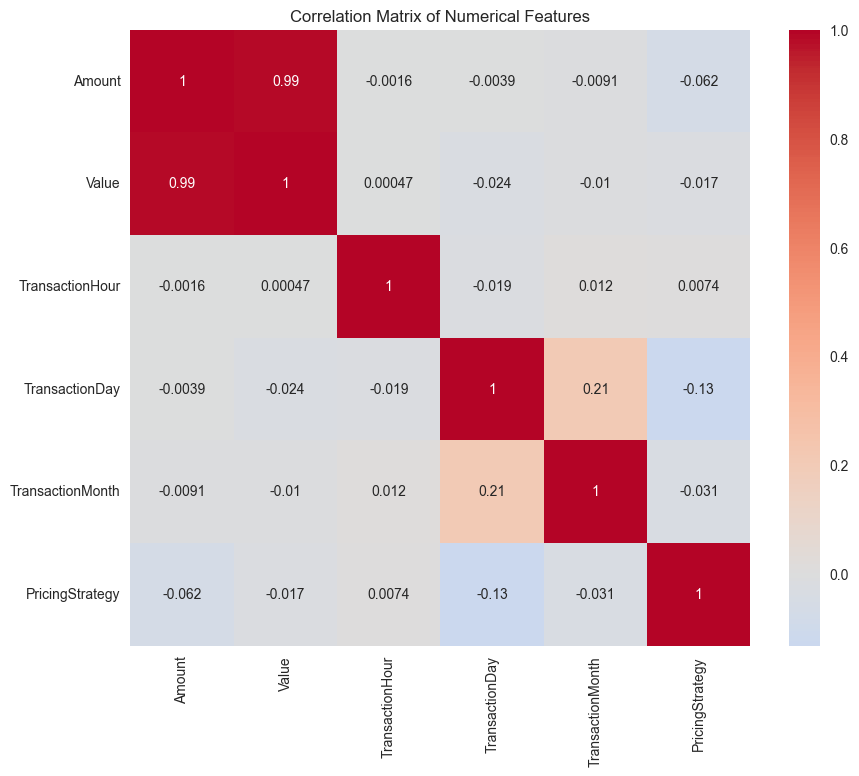

In [8]:
# Cell 7: Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df[['Amount', 'Value', 'TransactionHour', 'TransactionDay', 
                 'TransactionMonth', 'PricingStrategy']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [11]:
# Cell 8: RFM Metrics Preview (Fixed)
rfm = calculate_rfm(df)
print("\nRFM Summary Statistics:")
print(rfm.describe().round(2))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Recency Distribution (Days since last transaction)')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Frequency Distribution (Number of Transactions)')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='orange')
axes[2].set_title('Monetary Distribution (Total Value)')

plt.tight_layout()
plt.show()

print(f"\nTotal Customers: {len(rfm)}")

TypeError: Cannot subtract tz-naive and tz-aware datetime-like objects.